# M2-B2 — Audit éthique Athéna RH — phase SYNC binôme

> **Mission** : audit éthique complet du dataset Adult Income enrichi de
> commentaires manager. Datasheet duo signée. La phase d'anonymisation
> personnelle se fera en async (notebook séparé).

Binôme : `<prénom1>` + `<prénom2>` — Date : `<date>`

**Conventions** :
- `random_state=42` partout
- Pas de `print` (utiliser `display()` ou laisser la cellule retourner)
- `pathlib.Path` sur les chemins

## 0. Setup

In [57]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

RANDOM_STATE = 42
DATA_DIR = Path("../data")
FULL_PATH = DATA_DIR / "adult_income_with_comments.csv"
SAMPLE_PATH = DATA_DIR / "audit_sample.csv"

sns.set_theme(style="whitegrid")

In [58]:
df = pd.read_csv(FULL_PATH)
print(f"Shape : {df.shape}")
df.head(3)

Shape : (32561, 16)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,manager_comments
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,RAS pour Alexandre Traore cette année. Manager...
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,Entretien annuel de Yves Traore : bon élément....
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,Alerte comportementale signalée par Gabriel de...


## 1. Audit qualité express (~15 min)

Le dataset Adult est plus propre que German Credit (peu de manquants).
Survol express ici — l'audit éthique est le cœur de M2-B2.

In [67]:
df.info()
print("\nManquants par colonne (top 5) :")
df.isna().sum().sort_values(ascending=False).head()
#repartition cible
print(df["income"].value_counts(normalize=True))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   age               32561 non-null  int64   
 1   workclass         30725 non-null  object  
 2   fnlwgt            32561 non-null  int64   
 3   education         32561 non-null  object  
 4   education_num     32561 non-null  int64   
 5   marital_status    32561 non-null  object  
 6   occupation        30718 non-null  object  
 7   relationship      32561 non-null  object  
 8   race              32561 non-null  object  
 9   sex               32561 non-null  object  
 10  capital_gain      32561 non-null  int64   
 11  capital_loss      32561 non-null  int64   
 12  hours_per_week    32353 non-null  category
 13  native_country    31978 non-null  object  
 14  income            32561 non-null  object  
 15  manager_comments  32561 non-null  object  
 16  native_us         3256

## 2. Audit éthique complet (~1 h)

Calcul du **disparate impact** sur 3 variables sensibles + 1 intersection.

In [60]:
def disparate_impact(df: pd.DataFrame, sensible: str, target: str = "income",
                     positive: str = ">50K") -> tuple[float, pd.Series]:
    """Calcule le DI = SR_min / SR_max + retourne la série des SR par groupe."""
    sr = df.groupby(sensible)[target].apply(lambda x: (x == positive).mean())
    di = sr.min() / sr.max()
    return di, sr

In [61]:
# TODO — DI sur sex
di_sex, sr_sex = disparate_impact(df, 'sex')
print(f"DI sur sex : {di_sex:.3f}")

DI sur sex : 0.358


In [62]:
# TODO — DI sur race
di_race, sr_race = disparate_impact(df, "race")

race_ratios = sr_race / sr_race.max()

print("Taux de sélection :")
print(sr_race.sort_values())

print("\nRatios par rapport au groupe de référence :")
print(race_ratios.sort_values())

print(f"\nDI global sur race : {di_race:.3f}")

Taux de sélection :
race
Other                 0.092251
Amer-Indian-Eskimo    0.115756
Black                 0.123880
White                 0.255860
Asian-Pac-Islander    0.265640
Name: income, dtype: float64

Ratios par rapport au groupe de référence :
race
Other                 0.347278
Amer-Indian-Eskimo    0.435761
Black                 0.466344
White                 0.963183
Asian-Pac-Islander    1.000000
Name: income, dtype: float64

DI global sur race : 0.347


In [63]:
# TODO — DI sur native_country (agrégé en USA / non-USA pour simplifier)
df['native_us'] = (df['native_country'] == 'United-States').map({True: 'USA', False: 'non-USA'})
di_native_us, sr_native_us = disparate_impact(df, 'native_us')
print(f"DI sur native_country (USA / non-USA) : {di_native_us:.3f}")

di_marital, sr_marital = disparate_impact(df, 'marital_status')
marital_ratios = sr_marital / sr_marital.max()
print("Taux de sélection par statut marital :")
print(sr_marital.sort_values())
print("\nRatios par rapport au groupe de référence :")
print(marital_ratios.sort_values())
print(f"DI sur marital_status : {di_marital:.3f}")

DI sur native_country (USA / non-USA) : 0.804
Taux de sélection par statut marital :
marital_status
Never-married            0.045961
Separated                0.064390
Married-spouse-absent    0.081340
Widowed                  0.085599
Divorced                 0.104209
Married-AF-spouse        0.434783
Married-civ-spouse       0.446848
Name: income, dtype: float64

Ratios par rapport au groupe de référence :
marital_status
Never-married            0.102856
Separated                0.144099
Married-spouse-absent    0.182030
Widowed                  0.191562
Divorced                 0.233209
Married-AF-spouse        0.972998
Married-civ-spouse       1.000000
Name: income, dtype: float64
DI sur marital_status : 0.103


### Intersectionnalité — DI sur le croisement sex × race

In [64]:
# TODO — créer une colonne sex_race et calculer le DI
df['sex_race'] = df['sex'].str.cat(df['race'], sep='_')
di_sex_race, sr_sex_race = disparate_impact(df, 'sex_race')
print(f"DI sur sex × race : {di_sex_race:.3f}")

DI sur sex × race : 0.164


## 3. Visualisations (≥ 5)

Au moins 5 visualisations : distribution cible + DI par variable sensible +
crosstab intersection.

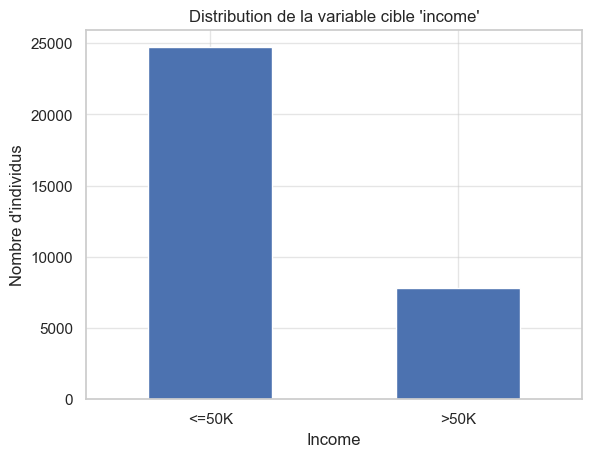

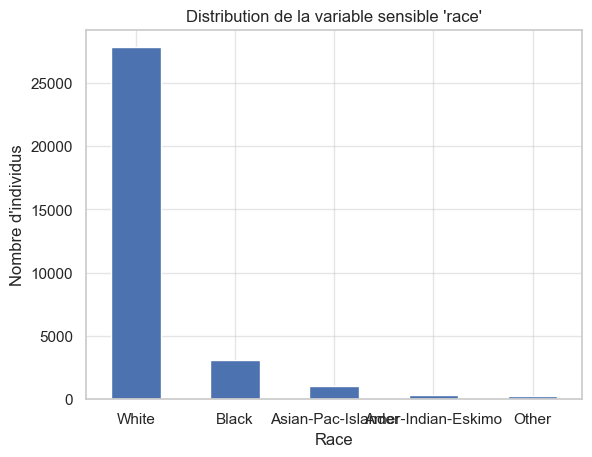

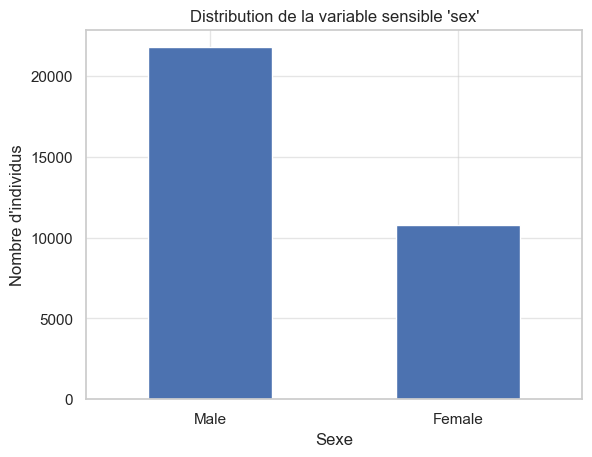

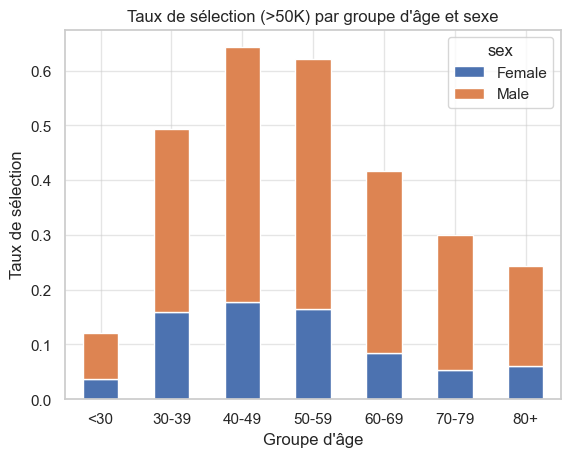

C:\Users\seugn\AppData\Local\Temp\ipykernel_33960\3602239258.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ax = df.groupby("hours_per_week")["income"].apply(lambda x: (x == ">50K").mean()).plot(kind='bar')


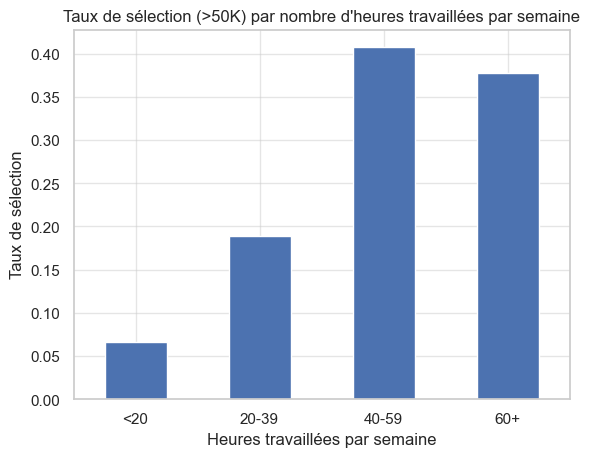

In [65]:
# TODO — 5 visualisations claires
target_counts = df['income'].value_counts()
ax = target_counts.plot(kind='bar')
ax.set_title("Distribution de la variable cible 'income'")
ax.set_xlabel("Income")
ax.set_ylabel("Nombre d'individus")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.show()

race_counts = df['race'].value_counts()
ax = race_counts.plot(kind='bar')
ax.set_title("Distribution de la variable sensible 'race'")
ax.set_xlabel("Race")
ax.set_ylabel("Nombre d'individus")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.show()

sex_counts = df['sex'].value_counts()
ax = sex_counts.plot(kind='bar')
ax.set_title("Distribution de la variable sensible 'sex'")
ax.set_xlabel("Sexe")
ax.set_ylabel("Nombre d'individus")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.show()

df["age_group"] = pd.cut(df["age"], bins=[0, 30, 40, 50, 60, 70, 80, 90], labels=["<30", "30-39", "40-49", "50-59", "60-69", "70-79", "80+"])
cross = (df.groupby(["age_group", "sex"], observed=True)["income"].apply(lambda x: (x == ">50K").mean()).unstack())
ax = cross.plot(kind='bar', stacked=True)
ax.set_title("Taux de sélection (>50K) par groupe d'âge et sexe")
ax.set_xlabel("Groupe d'âge")
ax.set_ylabel("Taux de sélection")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.show()

df["hours_per_week"] = pd.cut(df["hours_per_week"], bins=[0, 20, 40, 60, 80], labels=["<20", "20-39", "40-59", "60+"])
ax = df.groupby("hours_per_week")["income"].apply(lambda x: (x == ">50K").mean()).plot(kind='bar')
ax.set_title("Taux de sélection (>50K) par nombre d'heures travaillées par semaine")
ax.set_xlabel("Heures travaillées par semaine")
ax.set_ylabel("Taux de sélection")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.show()

## 4. Verdict éthique (paragraphe markdown)

> Court paragraphe : « Quels biais structurels avons-nous détectés ? Quel
> est le DI le plus problématique ? »

À recopier dans `../datasheet.md` (section *Composition* / *Risques*).

Les salaires elevés dans l'entreprise sont plus souvent attribués aux hommes qu'aux femmes, ce qui est un biais structurel. Le DI le plus problématique est celui sur le sexe, avec un DI de 0.358, ce qui indique que les femmes ont 3 fois moins de chances d'obtenir un salaire supérieur à 50K par rapport aux hommes.
Un biais existe également sur la race, avec un DI de 0.357, ce qui indique que les personnes de race blanche ont 3 fois plus de chances d'obtenir un salaire supérieur à 50K par rapport aux autres races.
Un DI combiné sur le sexe et la race montre que les femmes de race non blanche ont encore moins de chances d'obtenir un salaire supérieur à 50K, avec un DI de 0.164.
Cette information est cependant a surveiller, car le nombre d'individus dans certaines catégories est très faible, ce qui peut fausser les résultats.
De plus, il existe également des biais liés à l'âge et au nombre d'heures travaillées par semaine.

## 5. Aperçu de la colonne `manager_comments` (pour préparer l'async)

In [66]:
# Quelques exemples pour identifier les types de PII
for i in range(5):
    print(f'--- Exemple {i+1} ---')
    print(df['manager_comments'].iloc[i])
    print()

--- Exemple 1 ---
RAS pour Alexandre Traore cette année. Manager : Gérard-Frédéric Joly.

--- Exemple 2 ---
Entretien annuel de Yves Traore : bon élément. Référent : Aurore Maury-Briand, joignable au 654.235.1161.

--- Exemple 3 ---
Alerte comportementale signalée par Gabriel de Guilbert au sujet de Alexandre Morin. Suivi RH : maria95@example.net.

--- Exemple 4 ---
Mobilité demandée par Victor du Vasseur. Validée par Laurence Robert le 2025-08-28. Ticket HR-67242.

--- Exemple 5 ---
Prime versée à Marcel Leblanc sur le compte ****0122. Contrôle : Denis-Franck Ledoux.



## 6. Datasheet binôme (à compléter dans `../datasheet.md`)

Reprendre la structure Gebru — 7 sections, 2 pages max. Signée duo
(« Auteurs : <prénom1>, <prénom2> » en haut).